In [1]:
from pathlib import Path
import sys

# ── Project Root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Project Directories ───────────────────────────────────────────────────────
vocab_dir = PROJECT_ROOT / "artifacts" / "vocab"
checkpoints_dir = PROJECT_ROOT / "checkpoints"
reports_dir = PROJECT_ROOT / "reports"
figures_dir = reports_dir / "figures"
text_dir = reports_dir / "text"

In [2]:
from __future__ import annotations

from src.utils import load_checkpoint, plot_training_history, display_lr_curve
from src.dataloader import translation_dataset, src_vocab, tgt_vocab
from transformer.transformer import Transformer
from src.dataloader import config, train_cfg
from evaluating.eval import eval_model
from typing import List, TYPE_CHECKING
from src.vocabulary import Vocabulary
from pathlib import Path
import torch.nn as nn
import torch


import warnings
warnings.simplefilter(action= "ignore")
warnings.filterwarnings(action= "ignore", category=FutureWarning)

Saved Vocabulary: /home/adnan/Desktop/Translation-English-Arabic/artifacts/vocab/src_vocab.pt
Saved Vocabulary: /home/adnan/Desktop/Translation-English-Arabic/artifacts/vocab/tgt_vocab.pt


**Traning Dataset Summary**

In [3]:
translation_dataset.summary()

,Dataset,Samples,Min Length,Max Length
0,Source,15,4,19
1,Target,15,4,19


**Training Loss & Learning Rate Visualization.**

In [4]:
# ── Load Training Results ─────────────────────────────────────────────────────
training_results = torch.load(
    checkpoints_dir / "training_results.pt",
    weights_only=True,
)

epochs = training_results["epochs"]
train_acc = training_results["train_acc"]
lr_history = training_results["lr_history"]
train_losses = training_results["train_losses"]

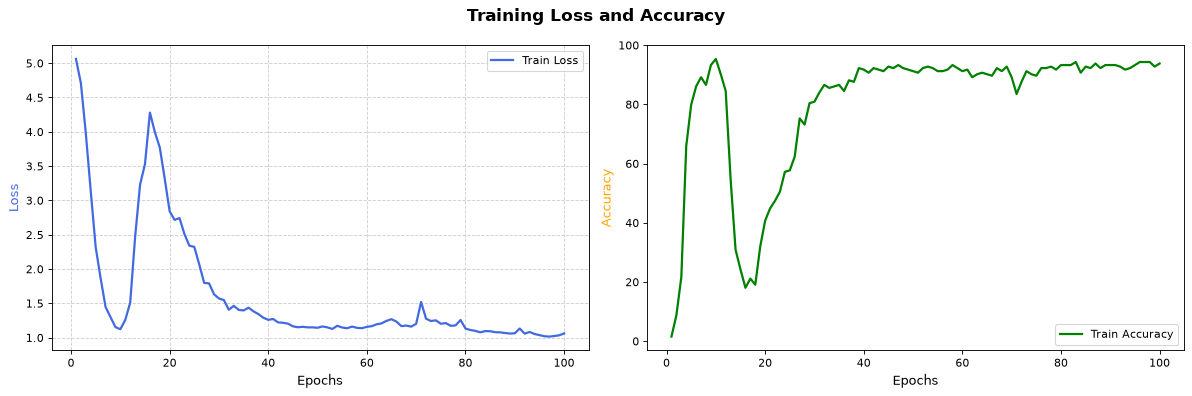

Training curves saved to: reports/figures/training_history.png


In [5]:
plot_training_history(epochs, train_losses, train_acc, display=True)

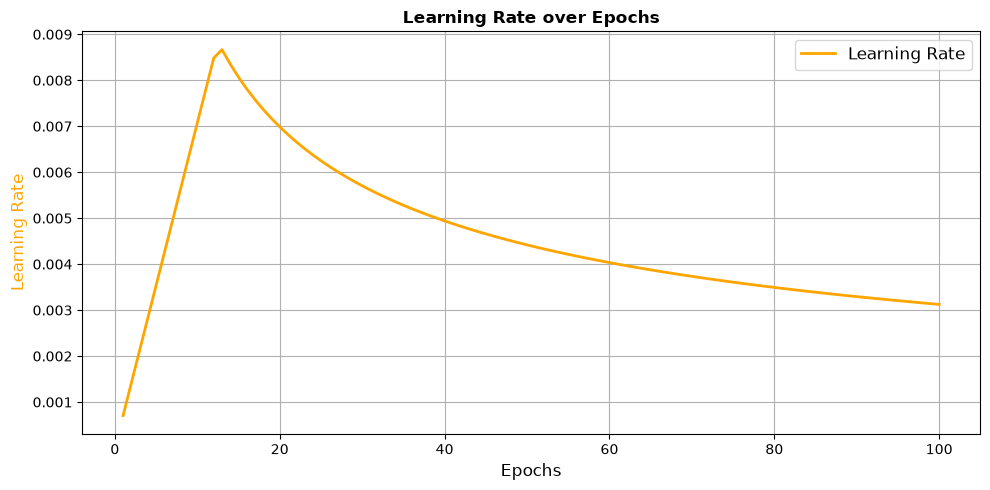

Learning rate curve saved to: reports/figures/learning_rate_curve.png


In [6]:
display_lr_curve(epochs, lr_history, display=True)

# **Step 1: Model Evaluation.**

In [7]:
# ── Instantiate model ────────────
translator = Transformer(**vars(config))

# ── Load State dictionary ────────
ckpt_path = checkpoints_dir / "best_checkpoint.pt"
ckpt = load_checkpoint(path = ckpt_path, device = train_cfg.device)

# ── Load weights ────────────────
translator.load_state_dict(ckpt['model_state_dict'])
translator = translator.to(train_cfg.device)

In [8]:
print(
    f"Checkpoint Epoch: {ckpt['epoch']}\n"
    f"Checkpoint Loss: {ckpt['train_loss']:.4f}\n"
    f"Checkpoint Accuracy: {ckpt['train_acc']:.2f}%"
)

Checkpoint Epoch: 97
Checkpoint Loss: 1.0156
Checkpoint Accuracy: 94.33%


In [9]:
print("=" * 35)
print("        Vocabulary Summary")
print("=" * 35)
print(f"Source Vocabulary Size : {len(src_vocab):>5}")
print(f"Target Vocabulary Size : {len(tgt_vocab):>5}")
print("=" * 35)

        Vocabulary Summary
Source Vocabulary Size :   155
Target Vocabulary Size :   150


In [10]:
# ── Define vocabulary file paths ──
src_vocab_path = vocab_dir / "src_vocab.pt"
tgt_vocab_path = vocab_dir / "tgt_vocab.pt"


eng_sentences = ["In the open fields, colorful flowers grow among the green grass and attract butterflies and bees.",
                 "Green forests stretch across the land, while small streams flow gently between the trees.",
                 "The Beauty of Nature."]

eval_model(
    translator=translator,
    max_len = config.max_seq_len,
    src_path=src_vocab_path,
    tgt_path=tgt_vocab_path,
    pad_idx = config.pad_idx,
    eng_sentences=eng_sentences,
    device=train_cfg.device
)

Encoder Input: tensor([[ 18,  19,  99, 100, 101, 102, 103, 104,  19, 105, 106,  26, 107, 108,
          26, 109],
        [ 32,  33,  34,  24,  19,  35,  36,  37,  38,  39,  40,  41,  19,  42,
           0,   0],
        [  2,   3,   4,   5,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0]])
Decoder Input: tensor([[2],
        [2],
        [2]])

English: In the open fields, colorful flowers grow among the green grass and attract butterflies and bees.
Arabic:  في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.
------------------------------------------------------------------------------------------------------------------------

English: Green forests stretch across the land, while small streams flow gently between the trees.
Arabic:  في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.
------------------------------------------------------------------------------------------------------------------------

Eng

# **Step 2: Error Analysis.**

## **Step 2.1: Inspect the Training Pair.**

In [11]:
# ── Inspect the fourth training pair ──
source_ids, target_ids = translation_dataset[3]

source_sentence = src_vocab.decode([source_ids])
target_sentence = tgt_vocab.decode([target_ids])

print("English:")
print(source_sentence)

print("\nArabic:")
print(target_sentence)

English:
['Green forests stretch across the land, while small streams flow gently between the trees.']

Arabic:
['تمتد الغابات الخضراء عبر الأرض، بينما تتدفق الجداول الصغيرة بهدوء بين الأشجار.']


## **Step 2.2: Teacher-Forced Evaluation.**
> Evaluate the model on the same training pair using teacher forcing and compare the predicted target tokens with the expected next tokens.

In [12]:
# Now let's perform teacher-forced evaluation on this exact training example.

# ── Get the second training pair ──
source_ids, target_ids = translation_dataset[1]

# ── Prepare source (English) sequence ──
encoder_input = torch.tensor(
    [source_ids],
    dtype=torch.long,
    device=train_cfg.device
)

# ── Prepare target (Arabic) sequence ──
target_tensor = torch.tensor(
    [target_ids],
    dtype=torch.long,
    device=train_cfg.device
)

# ── Teacher-forcing input ──
decoder_input = target_tensor[:, :-1]

# ── Expected next tokens ──
target_output = target_tensor[:, 1:]

# ── Run the trained model ──
with torch.inference_mode():
    logits = translator(
        encoder_input,
        decoder_input
    )

# ── Get predicted token IDs ──
predictions = logits.argmax(dim=-1)

print("Source:     ", encoder_input)
print("Target:     ", target_output)
print("Prediction: ", predictions)

Source:      tensor([[ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]])
Target:      tensor([[ 6,  4,  7,  8,  9, 10, 11, 12, 13,  3]])
Prediction:  tensor([[ 4,  4,  7,  8,  9, 10, 11, 12, 13,  3]])


## **Step 2.3: Analyze First-Token Prediction.**

* **The purpose is:**
  * Compare the target first Arabic token with the model's first predicted token for every training sentence.

* #### **Error Analysis Summary**

  - **Correct predictions:** 6 / 15 (**40.0%**)
  - **Incorrect predictions:** 9 / 15 (**60.0%**)
  - The model correctly predicts several content words such as **جمال، تملأ، تسطع، تذكرنا**.
  - Most errors occur on **function words and context-dependent words**, especially **في**, which is frequently predicted incorrectly.
  - The model also tends to repeat previously predicted tokens such as **في** and **جمال**, suggesting difficulty maintaining the correct sequential context.
  - Several target words such as **للطبيعة، تمتد، تتحرك، بالقرب، ترتفع، خلال، عند** were replaced by common tokens.
  - Overall, the errors indicate that the model can learn individual vocabulary items but still struggles with **contextual word selection and sequence-level translation**.

* **Summary Table**

<table align="center">
  <tr>
    <th>Metric</th>
    <th>Result</th>
  </tr>
  <tr>
    <td>Total tokens</td>
    <td>15</td>
  </tr>
  <tr>
    <td>Correct predictions</td>
    <td><strong>6 (40.0%)</strong></td>
  </tr>
  <tr>
    <td>Incorrect predictions</td>
    <td><strong>9 (60.0%)</strong></td>
  </tr>
  <tr>
    <td>Main error pattern</td>
    <td>Repetition of common tokens</td>
  </tr>
  <tr>
    <td>Most frequent incorrect prediction</td>
    <td><strong>في</strong></td>
  </tr>
  <tr>
    <td>Commonly confused words</td>
    <td><strong>في، جمال</strong></td>
  </tr>
  <tr>
    <td>Key weakness</td>
    <td>Contextual word selection</td>
  </tr>
  <tr>
    <td>Overall observation</td>
    <td>Good recognition of some individual words, but weak sequence/context modeling</td>
  </tr>
</table>

In [13]:
# ── Test first-token prediction for every training sentence ──
translator.eval()

with torch.inference_mode():

    for index in range(len(translation_dataset)):

        # ── Get source and target IDs ──
        source_ids, target_ids = translation_dataset[index]

        # ── Prepare source sequence ──
        encoder_input = torch.tensor(
            [source_ids],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Prepare target sequence ──
        target_tensor = torch.tensor(
            [target_ids],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Use only <BOS> as decoder input ──
        decoder_input = target_tensor[:, :1]

        # ── Run model ──
        logits = translator(
            encoder_input,
            decoder_input
        )

        # ── First predicted token ──
        predicted_id = logits[:, -1, :].argmax(dim=-1).item()

        # ── Correct first token ──
        target_id = target_tensor[:, 1].item()

        # ── Convert IDs to words ──
        predicted_word = tgt_vocab.idx_to_word[predicted_id]
        target_word = tgt_vocab.idx_to_word[target_id]

        print(
            f"{index:2d} | "
            f"Target: {target_word:<15} | "
            f"Predicted: {predicted_word:<15} | "
            f"{'✓' if predicted_id == target_id else '✗'}"
        )

 0 | Target: جمال            | Predicted: جمال            | ✓
 1 | Target: للطبيعة         | Predicted: جمال            | ✗
 2 | Target: في              | Predicted: في              | ✓
 3 | Target: تمتد            | Predicted: في              | ✗
 4 | Target: تملأ            | Predicted: تملأ            | ✓
 5 | Target: في              | Predicted: جمال            | ✗
 6 | Target: تتحرك           | Predicted: في              | ✗
 7 | Target: بالقرب          | Predicted: في              | ✗
 8 | Target: ترتفع           | Predicted: في              | ✗
 9 | Target: في              | Predicted: في              | ✓
10 | Target: خلال            | Predicted: في              | ✗
11 | Target: عند             | Predicted: في              | ✗
12 | Target: تسطع            | Predicted: تسطع            | ✓


13 | Target: في              | Predicted: جمال            | ✗
14 | Target: تذكرنا          | Predicted: تذكرنا          | ✓


## **Step 2.4: Autoregressive Prediction Analysis.**

**Analysis:**

- The model generates the first two training sentences correctly, but for many later sentences it produces a complete translation from another training example instead of translating the given source sentence.
- This shows that autoregressive generation can fail even when teacher-forced predictions are correct, indicating that the model is not reliably conditioning its generated sequence on the source sentence.

In [14]:
# ── Test autoregressive prediction for every training sentence ──
translator.eval()

with torch.inference_mode():

    for index in range(len(translation_dataset)):

        # ── Get source and target IDs ──
        source_ids, target_ids = translation_dataset[index]

        # ── Prepare source sequence ──
        encoder_input = torch.tensor(
            [source_ids],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Start decoder with <BOS> ──
        decoder_input = torch.tensor(
            [[tgt_vocab.BOS_IDX]],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Generate translation ──
        for _ in range(config.max_seq_len):

            logits = translator(
                encoder_input,
                decoder_input
            )

            # ── Predict next token ──
            predicted_id = logits[:, -1, :].argmax(dim=-1)

            # ── Stop at <EOS> ──
            if predicted_id.item() == tgt_vocab.EOS_IDX:
                break

            # ── Append predicted token ──
            decoder_input = torch.cat(
                [decoder_input, predicted_id[:, None]],
                dim=1
            )

        # ── Decode target and prediction ──
        target_sentence = tgt_vocab.decode([target_ids])[0]
        predicted_sentence = tgt_vocab.decode(
            [decoder_input[0].tolist()]
        )[0]

        print(f"\n{'=' * 100}")
        print(f"Index:      {index}")
        print(f"Target:     {target_sentence}")
        print(f"Prediction: {predicted_sentence}")


Index:      0
Target:     جمال الطبيعة.
Prediction: جمال الطبيعة.

Index:      1
Target:     للطبيعة جمال هادئ يمكن العثور عليه في أماكن كثيرة.
Prediction: جمال الطبيعة.

Index:      2
Target:     في الصباح الباكر، ينتشر ضوء الشمس فوق الجبال ويمنح السماء لونًا ذهبيًا دافئًا.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.



Index:      3
Target:     تمتد الغابات الخضراء عبر الأرض، بينما تتدفق الجداول الصغيرة بهدوء بين الأشجار.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.



Index:      4
Target:     تملأ الطيور الهواء بأغانيها، ويداعب نسيم لطيف أوراق الأشجار.
Prediction: تملأ الطيور الهواء بأغانيها، ويداعب نسيم لطيف أوراق الأشجار.

Index:      5
Target:     في أعماق الغابة، تصنع الأشجار العالية ظلالًا باردة تجد فيها العديد من الحيوانات مأوى.
Prediction: جمال الطبيعة.

Index:      6
Target:     تتحرك بعض الحيوانات بهدوء بين الأغصان، بينما يبحث بعضها الآخر عن الطعام بالقرب من الأرض.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.



Index:      7
Target:     بالقرب من الساحل، تعكس المياه الزرقاء الصافية ضوء الشمس وتصنع أنماطًا جميلة على طول الشاطئ.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.



Index:      8
Target:     ترتفع الأمواج وتهبط برفق، مُصدرة صوتًا هادئًا يمكن سماعه من مسافة بعيدة.
Prediction: في الصباح الباكر، ينتشر ضوء الشمس فوق الجبال ويمنح السماء لونًا ذهبيًا دافئًا.



Index:      9
Target:     في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.



Index:      10
Target:     خلال فصل الربيع، تمتلئ الحقول بالحياة بينما تبدأ النباتات الجديدة في النمو وتنمو على الأشجار أوراق جديدة.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.

Index:      11
Target:     عند غروب الشمس، تتغير السماء ببطء من الأزرق إلى البرتقالي والوردي والبنفسجي الداكن.
Prediction: في الحقول المفتوحة، تنمو الزهور الملونة بين العشب الأخضر وتجذب الفراشات والنحل.



Index:      12
Target:     تسطع أشعة الشمس الأخيرة فوق الجبال وتختفي خلف الأفق البعيد.
Prediction: تسطع أشعة الشمس الأخيرة فوق الجبال وتختفي خلف الأفق البعيد.

Index:      13
Target:     في الليل، تصبح أصوات الطبيعة أكثر هدوءًا، وتظهر النجوم بوضوح في السماء المظلمة.
Prediction: جمال الطبيعة.



Index:      14
Target:     تذكرنا هذه المشاهد البسيطة بأن الطبيعة يمكن أن تكون هادئة وجميلة ومليئة بالحياة.
Prediction: تذكرنا هذه المشاهد البسيطة بأن الطبيعة يمكن أن تكون هادئة وجميلة ومليئة بالحياة.


# **Step 3: Experiments.**

**Experiments:**
- Multiple experiments were conducted by modifying the Transformer configuration to investigate the effect of different hyperparameters and training settings on model performance. 
- For each experiment, the configuration was updated in the configuration file, the model was retrained, and the training behavior and evaluation results were recorded for comparison.

# ── Experiment 1: Large Transformer Baseline ──

**Configuration:**  
- Batch size: 2
- $d_{model}$: 512
- Expansion dimension: 2048
- Attention heads: 8
- Transformer layers: 6
- Maximum sequence length: 100
- Epochs: 100
- Warmup steps: 4000

**Observations:**  
- The model learned rapidly during the first 30 epochs, with training accuracy increasing from **12.37% at Epoch 10** to **99.49% at Epoch 30**.
- The model reached **100% training accuracy by Epoch 40** and maintained approximately 100% accuracy for the remainder of training.
- Training loss decreased substantially from **4.260 at Epoch 10** to around **0.85** after Epoch 40.
- The learning rate increased gradually throughout training, reaching **0.000140 by Epoch 100** because the model was still within the warmup phase.
- Training remained stable despite the increasing learning rate, with only a small fluctuation around Epoch 70.
- The best checkpoint was saved at **Epoch 93**, achieving a training loss of **0.8484**.

**Conclusion:**  
> The model learned the training set successfully and reached near-perfect training accuracy relatively early. Training remained stable throughout the 100 epochs, although the 4000-step warmup meant that the learning rate was still increasing at the end of training. The best checkpoint was obtained at Epoch 93 with a loss of 0.8484.

![Experiment 1 Training Curves](../reports/figures/exp1_training.png)

# ── Experiment 2: Large Transformer with Short Warmup ──

**Configuration:**  
- Batch size: 2
- $d_{model}$: 512
- Expansion dimension: 2048
- Attention heads: 8
- Transformer layers: 6
- Maximum sequence length: 100
- Epochs: 100
- Warmup steps: 100

**Observations:**  
- Training failed to make meaningful progress throughout the experiment.
- Training accuracy remained fixed at **7.732%** from Epoch 10 through Epoch 100.
- Training loss decreased slowly from **5.193 at Epoch 10** to **4.824 at Epoch 100**, but this reduction did not correspond to an improvement in accuracy.
- The learning rate started relatively high, reaching **0.003536 at Epoch 10**, then gradually decreased throughout training.
- The model appears to have entered a stagnant training state, with almost no change in prediction accuracy.
- The best checkpoint was saved at **Epoch 5**, with a loss of **4.1519**.

**Conclusion:**  
> The model failed to learn effectively with only 100 warmup steps. Despite a gradual reduction in training loss, accuracy remained stuck at 7.732% for the entire experiment. The high learning rate early in training may have contributed to the failure to converge, indicating that the warmup and learning-rate configuration requires further investigation.

![Experiment 1 Training Curves](../reports/figures/exp2_training.png)

# ── Experiment 3: Smaller Transformer with Short Warmup ──

**Configuration:**  
- Batch size: 2
- $d_{model}$: 128
- Expansion dimension: 512
- Attention heads: 4
- Transformer layers: 2
- Maximum sequence length: 32
- Epochs: 100
- Warmup steps: 100

**Observations:**  
- The smaller model learned rapidly, reaching **96.39% training accuracy by Epoch 10**.
- Training became unstable around Epoch 20, where accuracy dropped significantly to **55.16%** and loss increased to **2.340**.
- After Epoch 20, the model recovered progressively, reaching approximately **92.78% accuracy by Epoch 50**.
- From Epoch 50 onward, training remained relatively stable, with accuracy fluctuating around **90.72–92.78%**.
- Training loss gradually decreased after the instability at Epoch 20, reaching **1.054 by Epoch 100**.
- The learning rate decreased from **0.007071 at Epoch 10** to **0.003125 at Epoch 100**.
- The best checkpoint was saved at **Epoch 95**, with a loss of **1.0525**.

**Conclusion:**  
> The smaller Transformer successfully learned the training data, reaching high accuracy early in training. However, the experiment showed noticeable instability around Epoch 20, followed by recovery and stabilization. Compared with Experiment 2, this configuration demonstrated substantially better learning behavior despite using a much smaller model. The best checkpoint was obtained at Epoch 95 with a loss of 1.0525.

![Experiment 1 Training Curves](../reports/figures/exp3_training.png)

# ── Experiment 4: Large Transformer with Extended Training ──

**Configuration:**  
- Batch size: 2
- $d_{model}$: 512
- Expansion dimension: 2048
- Attention heads: 8
- Transformer layers: 6
- Maximum sequence length: 100
- Epochs: 700
- Warmup steps: 4000

**Observations:**  
- The model initially reached **100% training accuracy** by Epoch 50 and maintained it through Epoch 250.
- Training performance began to deteriorate after approximately **Epoch 300**, while the learning rate continued increasing during the warmup phase.
- Training accuracy gradually dropped from **97.94% at Epoch 300** to **86.60% at Epoch 500**.
- After the learning rate reached its peak, training accuracy temporarily recovered to **92.27% at Epoch 600**, but later dropped to **65.98% by Epoch 700**.
- The best checkpoint was obtained at **Epoch 324**, with a training loss of **0.8282**.
- The results suggest that the increasing learning rate during the long warmup period eventually caused training instability and degradation.

**Conclusion:**  
> The model successfully learned the training data early, reaching 100% training accuracy, but prolonged training with a 4000-step warmup caused performance degradation. The best checkpoint occurred around Epoch 324, after which the increasing learning rate was associated with unstable training and a substantial drop in accuracy.

![]()

![Experiment 1 Training Curves](../reports/figures/exp4_training.png)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Implementation Successfully Completed.</div>